### 1. Visualización con matplotlib y searborn
En este notebook se construye un reporte visual para resumir el comportamiento general de las ventas.

In [1]:
# Cargar librerías, leer la tabla de ventas y definir el estilo visual del reporte.
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine("sqlite:///../db/ventas.db", echo=False)
df = pd.read_sql("SELECT * FROM ventas", engine)

# ESTILO MODERNO
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": False,
        "axes.spines.bottom": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "grid.linestyle": "--",
        "axes.facecolor": "#F8F9FA",
        "figure.facecolor": "#FFFFFF",
        "axes.titlepad": 15,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
    }
)

PALETTE_PIE = sns.color_palette("pastel")
PALETTE_BAR = sns.color_palette("Blues_r", 10)
PALETTE_CAT = sns.color_palette("pastel")
PALETTE_BOX = sns.color_palette("Set2")

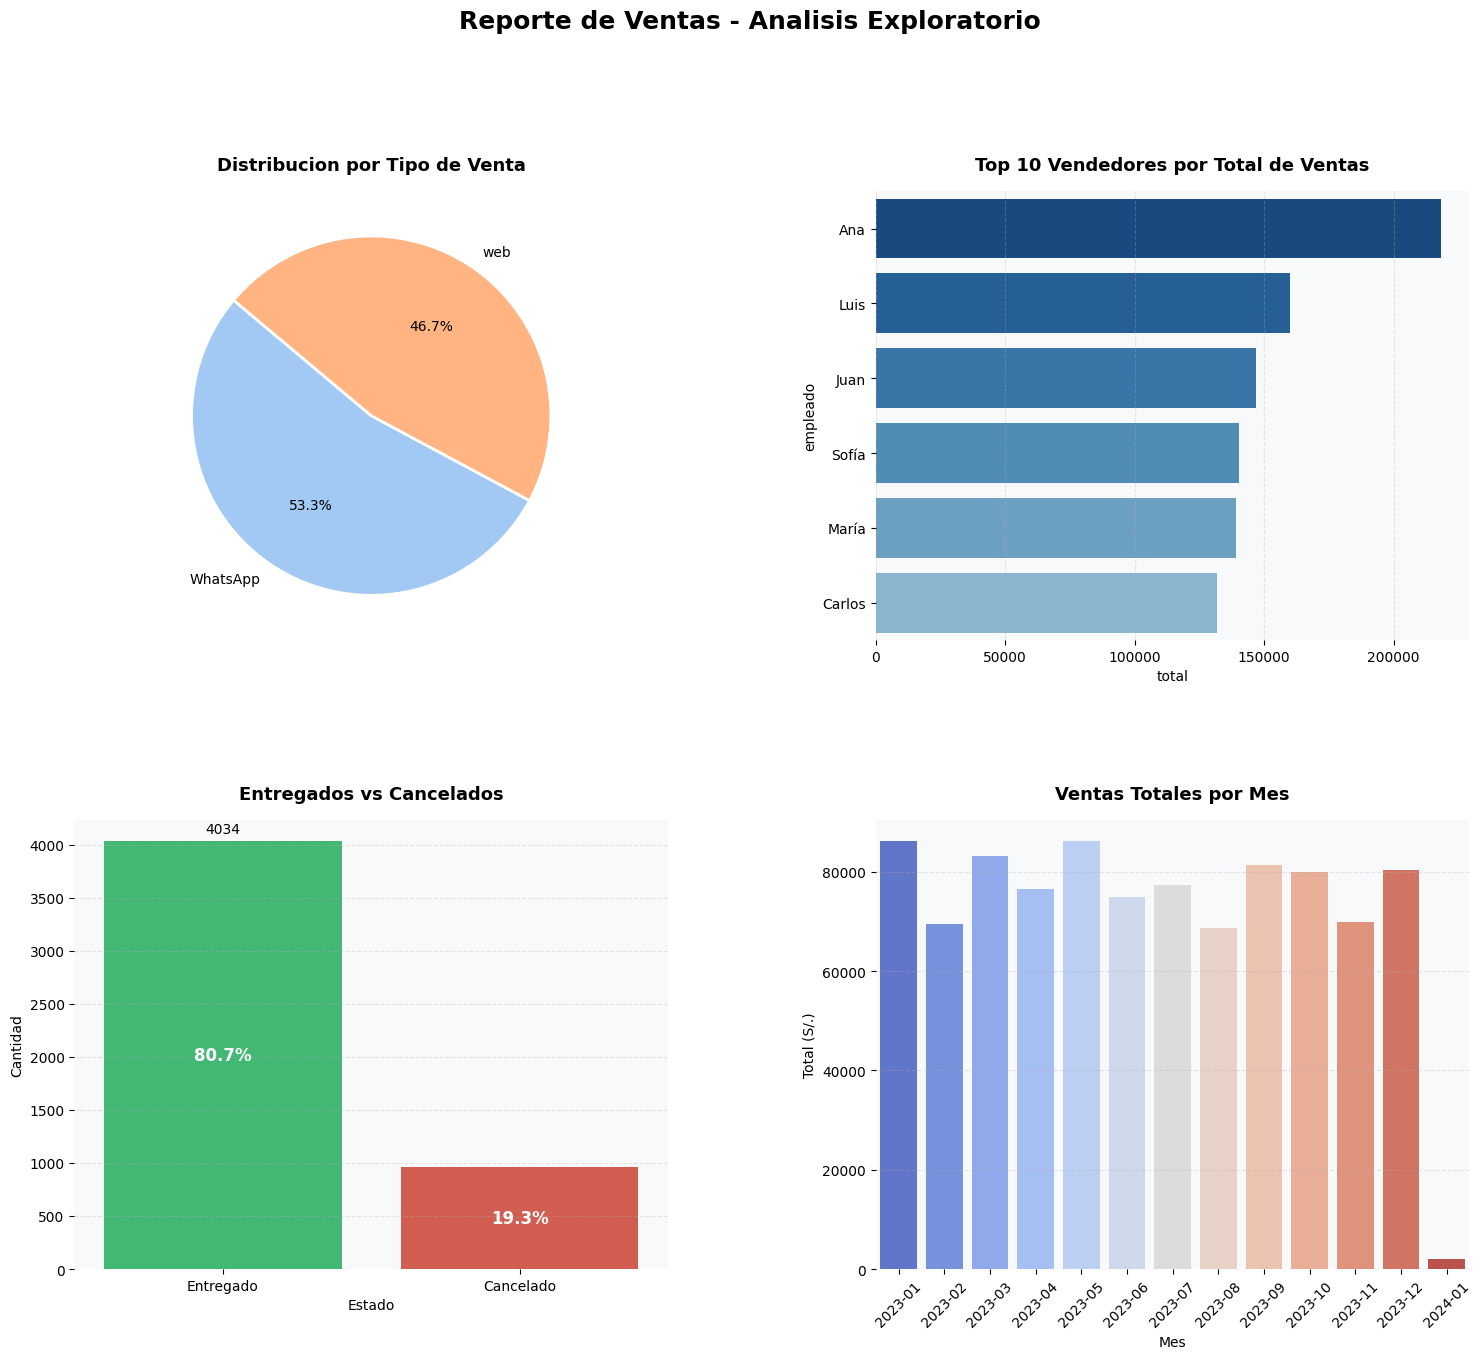

Reporte guardado en ../reports/reporte_completo.png


In [ ]:
# Construir un tablero 2x2 con métricas clave y exportarlo como imagen para el informe final.
import os

# LAYOUT - 2x2
fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    "Reporte de Ventas - Analisis Exploratorio", fontsize=18, fontweight="bold", y=1.01
)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# 1. Distribucion por tipo de venta
ventas_tipo = df.groupby("tipo_venta")["total"].sum()

wedges, texts, autotexts = ax1.pie(
    ventas_tipo.values,
    labels=ventas_tipo.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=PALETTE_PIE,
    wedgeprops=dict(edgecolor="white", linewidth=2),
    textprops=dict(fontsize=10),
)
ax1.set_title("Distribucion por Tipo de Venta")

# 2. BAR - Top 10 vendedores
top_vendedores = (
    df.groupby("empleado")["total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

bars = sns.barplot(
    x="total",
    y="empleado",
    data=top_vendedores,
    hue="empleado",
    legend=False,
    palette=PALETTE_BAR[: len(top_vendedores)],
    ax=ax2,
)
ax2.set_title("Top 10 Vendedores por Total de Ventas")

# 3. BAR - Entregados vs Cancelados
entregados = df["es_entregado"].value_counts().reset_index()
entregados.columns = ["estado", "cantidad"]
entregados["estado"] = entregados["estado"].map({1: "Entregado", 0: "Cancelado"})

bars3 = sns.barplot(
    x="estado",
    y="cantidad",
    data=entregados,
    hue="estado",
    legend=False,
    palette={"Entregado": "#2ecc71", "Cancelado": "#e74c3c"},
    ax=ax3,
)
ax3.set_title("Entregados vs Cancelados")
ax3.set_xlabel("Estado")
ax3.set_ylabel("Cantidad")
ax3.bar_label(bars3.containers[0], fmt="%d", padding=4, fontsize=10)

# Agregar porcentaje como texto debajo
total_ventas = len(df)
for bar, (_, row) in zip(bars3.patches, entregados.iterrows()):
    pct = row["cantidad"] / total_ventas * 100
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f"{pct:.1f}%",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color="white",
    )


# 4. BAR - Ventas por mes
df["fecha_venta"] = pd.to_datetime(df["fecha_venta"])  # <- fix
df["mes"] = df["fecha_venta"].dt.to_period("M").astype(str)

ventas_mes = df.groupby("mes")["total"].sum().reset_index()

sns.barplot(
    x="mes",
    y="total",
    data=ventas_mes,
    hue="mes",
    legend=False,
    palette=sns.color_palette("coolwarm", len(ventas_mes)),
    ax=ax4,
)
ax4.set_title("Ventas Totales por Mes")
ax4.set_xlabel("Mes")
ax4.set_ylabel("Total (S/.)")
ax4.tick_params(axis="x", rotation=45)

# GUARDAR
os.makedirs("../reports", exist_ok=True)
plt.savefig("../reports/reporte_completo.png", dpi=150, bbox_inches="tight")
plt.show()
print("Reporte guardado en ../reports/reporte_completo.png")